# EDAノートブック

本ノートブックは、分析業務で使うEDAを固定手順で実行するための定型版です。
可視化結果は相対パスで `reports/figures` に保存します。


## 固定EDA計画
1. データ読み込みと基本確認
2. 列型・記述統計の確認
3. 欠損率の集計と可視化
4. 数値列の分布確認
5. カテゴリ列の主要分布確認
6. 目的変数の分布と偏り確認
7. 数値特徴量の相関確認
8. 日付列の時系列傾向確認（存在時）
9. 観察結果サマリ


In [1]:
from pathlib import Path
import warnings

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")
warnings.filterwarnings("ignore", message="Glyph .* missing from font")
plt.rcParams["axes.unicode_minus"] = False

JP_FONT_CANDIDATES = [
    "Yu Gothic",
    "Meiryo",
    "MS Gothic",
    "Noto Sans CJK JP",
    "IPAexGothic",
    "IPAGothic",
    "TakaoGothic",
]


def configure_japanese_font() -> str:
    available = {f.name for f in fm.fontManager.ttflist}
    for name in JP_FONT_CANDIDATES:
        if name in available:
            plt.rcParams["font.family"] = name
            return name
    plt.rcParams["font.sans-serif"] = JP_FONT_CANDIDATES + list(plt.rcParams.get("font.sans-serif", []))
    return ""


selected_font = configure_japanese_font()
if selected_font:
    print(f"日本語フォント: {selected_font}")
else:
    print("日本語フォント候補が見つからないため、既定フォントで描画します。")

ENCODINGS = ("utf-8-sig", "utf-8", "cp932", "shift_jis", "euc_jp")

cwd = Path.cwd()
if (cwd / "configs" / "project_config.json").exists():
    analysis_root = cwd
elif (cwd.name == "notebooks") and (cwd.parent / "configs" / "project_config.json").exists():
    analysis_root = cwd.parent
elif (cwd / "artifacts" / "analysis_project" / "configs" / "project_config.json").exists():
    analysis_root = cwd / "artifacts" / "analysis_project"
else:
    analysis_root = cwd

FIG_DIR = analysis_root / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def load_csv_auto(path: Path):
    sep = "	" if path.suffix.lower() == ".tsv" else ","
    for enc in ENCODINGS:
        try:
            return pd.read_csv(path, encoding=enc, sep=sep), enc
        except UnicodeDecodeError:
            continue
    raise RuntimeError("CSVを既知エンコーディングで読み込めませんでした")


def is_pure_day_number_column(series: pd.Series) -> bool:
    numeric = pd.to_numeric(series, errors="coerce").dropna()
    if numeric.empty:
        return False
    if not np.all(np.isclose(numeric, np.round(numeric))):
        return False
    return bool(((numeric >= 1) & (numeric <= 31)).all())


日本語フォント: Yu Gothic


In [2]:
csv_rel = Path("data/train.csv")
candidates = [
    analysis_root / csv_rel,
    Path("data/train.csv"),
    Path("artifacts/analysis_project") / csv_rel,
]
csv_path = next((p for p in candidates if p.exists()), candidates[0])
df, used_encoding = load_csv_auto(csv_path)
target_col = "disease"
if target_col not in df.columns:
    target_col = df.columns[-1]
date_col_hint = "None".strip() or None

print(f"読み込みエンコーディング: {used_encoding}")
print(f"行数: {len(df):,} / 列数: {df.shape[1]:,}")
print(f"目的変数列: {target_col}")
display(df.head(10))


読み込みエンコーディング: utf-8-sig
行数: 3,500 / 列数: 12
目的変数列: disease


,id,Age,Gender,T_Bil,D_Bil,ALP,ALT_GPT,AST_GOT,TP,Alb,AG_ratio,disease
0,0,42,Male,0.786362,0.154075,162.267801,26.053979,37.413395,6.041335,3.584788,0.793957,1
1,1,65,Female,0.939515,0.174262,175.315396,14.346785,11.606569,6.249220,3.499155,0.954351,0
2,2,29,Male,1.221597,0.374223,151.164721,13.226549,11.109054,6.752648,3.498901,1.065019,1
3,3,65,Female,0.889107,0.122545,177.429034,15.376386,15.247101,6.333087,3.440847,0.953817,0
4,4,59,Male,1.990933,0.603734,183.793499,23.202757,54.162685,6.128990,2.560995,0.958612,0
5,5,53,Male,0.876721,0.162196,171.468926,15.367933,14.953179,6.309518,2.881901,0.726222,0
6,6,48,Male,1.847723,0.472662,274.482501,18.809777,28.759573,7.568808,4.386261,0.994752,0
7,7,18,Male,1.021282,0.181434,174.483153,11.926752,19.422232,5.906837,3.029505,0.746890,1
8,8,44,Male,0.963629,0.172137,196.762760,14.140577,16.915775,6.283292,4.181382,1.048648,1
9,9,62,Male,0.825142,0.141229,165.875721,23.910317,37.355509,7.083741,4.137601,1.015405,0


## 1. データ概要


In [3]:
try:
    overview = pd.DataFrame({
        '列名': df.columns,
        'データ型': [str(df[c].dtype) for c in df.columns],
        '欠損数': [int(df[c].isna().sum()) for c in df.columns],
        '欠損率(%)': [float(df[c].isna().mean() * 100) for c in df.columns],
        'ユニーク数': [int(df[c].nunique(dropna=True)) for c in df.columns]
    })
    print('データ概要')
    print(f'行数: {df.shape[0]}')
    print(f'列数: {df.shape[1]}')
    print('先頭5行')
    print(df.head())
    print('列情報')
    print(overview)
    print('数値列の要約統計量')
    print(df.describe(include=[np.number]).T)
    print('カテゴリ列の要約統計量')
    obj_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    if len(obj_cols) > 0:
        print(df[obj_cols].describe().T)
    else:
        print('カテゴリ列はありません')
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: overview_code: {_eda_exc}")
    dtype_summary = (
        df.dtypes.astype(str)
        .rename("dtype")
        .reset_index()
        .rename(columns={"index": "column"})
    )
    type_counts = dtype_summary["dtype"].value_counts().rename_axis("dtype").reset_index(name="count")
    print("列型サマリ")
    display(type_counts)
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    category_cols = [c for c in df.columns if c not in numeric_cols]
    print(f"数値列数: {len(numeric_cols)} / カテゴリ列数: {len(category_cols)}")
    display(dtype_summary.head(30))


データ概要
行数: 3500
列数: 12
先頭5行
   id  Age  Gender     T_Bil     D_Bil         ALP    ALT_GPT    AST_GOT  \
0   0   42    Male  0.786362  0.154075  162.267801  26.053979  37.413395   
1   1   65  Female  0.939515  0.174262  175.315396  14.346785  11.606569   
2   2   29    Male  1.221597  0.374223  151.164721  13.226549  11.109054   
3   3   65  Female  0.889107  0.122545  177.429034  15.376386  15.247101   
4   4   59    Male  1.990933  0.603734  183.793499  23.202757  54.162685   

         TP       Alb  AG_ratio  disease  
0  6.041335  3.584788  0.793957        1  
1  6.249220  3.499155  0.954351        0  
2  6.752648  3.498901  1.065019        1  
3  6.333087  3.440847  0.953817        0  
4  6.128990  2.560995  0.958612        0  
列情報
          列名     データ型  欠損数  欠損率(%)  ユニーク数
0         id    int64    0     0.0   3500
1        Age    int64    0     0.0     64
2     Gender      str    0     0.0      2
3      T_Bil  float64    0     0.0   3500
4      D_Bil  float64    0     0.0   3500
5 

       count unique   top  freq
Gender  3500      2  Male  2930


C:\Users\hikeshita\AppData\Local\Temp\ipykernel_26524\3746271782.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


## 2. 欠損分析


欠損状況
          列名  欠損数  欠損率(%)
0         id    0     0.0
1        Age    0     0.0
2     Gender    0     0.0
3      T_Bil    0     0.0
4      D_Bil    0     0.0
5        ALP    0     0.0
6    ALT_GPT    0     0.0
7    AST_GOT    0     0.0
8         TP    0     0.0
9        Alb    0     0.0
10  AG_ratio    0     0.0
11   disease    0     0.0


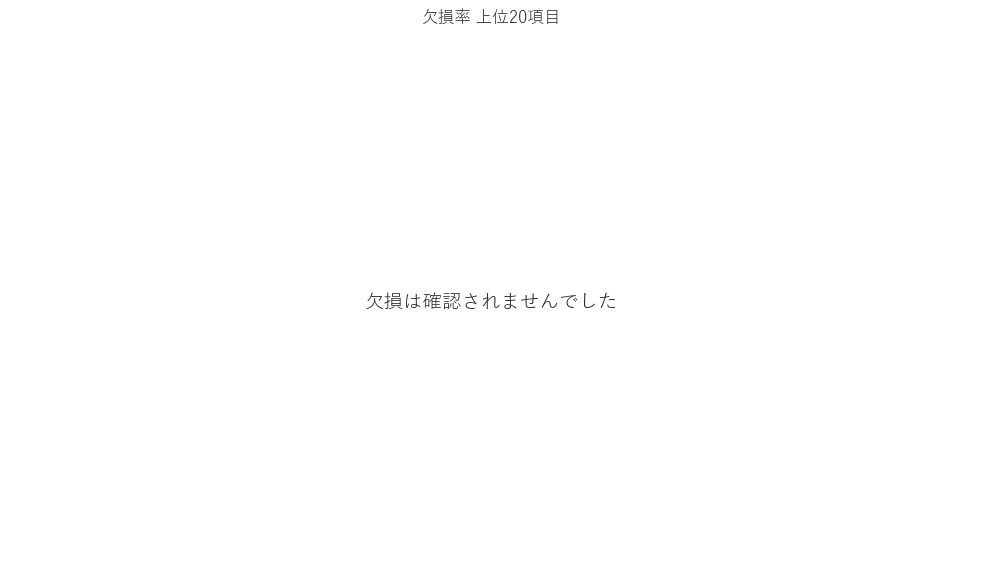

In [4]:
try:
    missing_df = df.isna().sum().sort_values(ascending=False).reset_index()
    missing_df.columns = ['列名', '欠損数']
    missing_df['欠損率(%)'] = missing_df['欠損数'] / len(df) * 100
    print('欠損状況')
    print(missing_df)
    plot_df = missing_df[missing_df['欠損数'] > 0].head(20)
    plt.figure(figsize=(10, 6))
    if len(plot_df) > 0:
        sns.barplot(data=plot_df, x='欠損率(%)', y='列名', palette='Reds_r')
        plt.title('欠損率 上位20項目')
        plt.xlabel('欠損率(%)')
        plt.ylabel('列名')
    else:
        plt.text(0.5, 0.5, '欠損は確認されませんでした', ha='center', va='center', fontsize=14)
        plt.title('欠損率 上位20項目')
        plt.axis('off')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'missing_rate_top20.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: missing_code: {_eda_exc}")
    missing_rate = (df.isna().mean() * 100).sort_values(ascending=False)
    display(missing_rate.rename("欠損率(%)").to_frame().head(20))
    top_missing = missing_rate.head(20)
    fig, ax = plt.subplots(figsize=(12, 5))
    top_missing.plot(kind="bar", ax=ax, color="#4c78a8")
    ax.set_title("欠損率 上位20列")
    ax.set_ylabel("欠損率(%)")
    ax.set_xlabel("列名")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "missing_rate_top20.png", dpi=160, bbox_inches="tight")
    plt.show()


## 3. 数値特徴量の分布


数値列一覧
['id', 'Age', 'T_Bil', 'D_Bil', 'ALP', 'ALT_GPT', 'AST_GOT', 'TP', 'Alb', 'AG_ratio', 'disease']


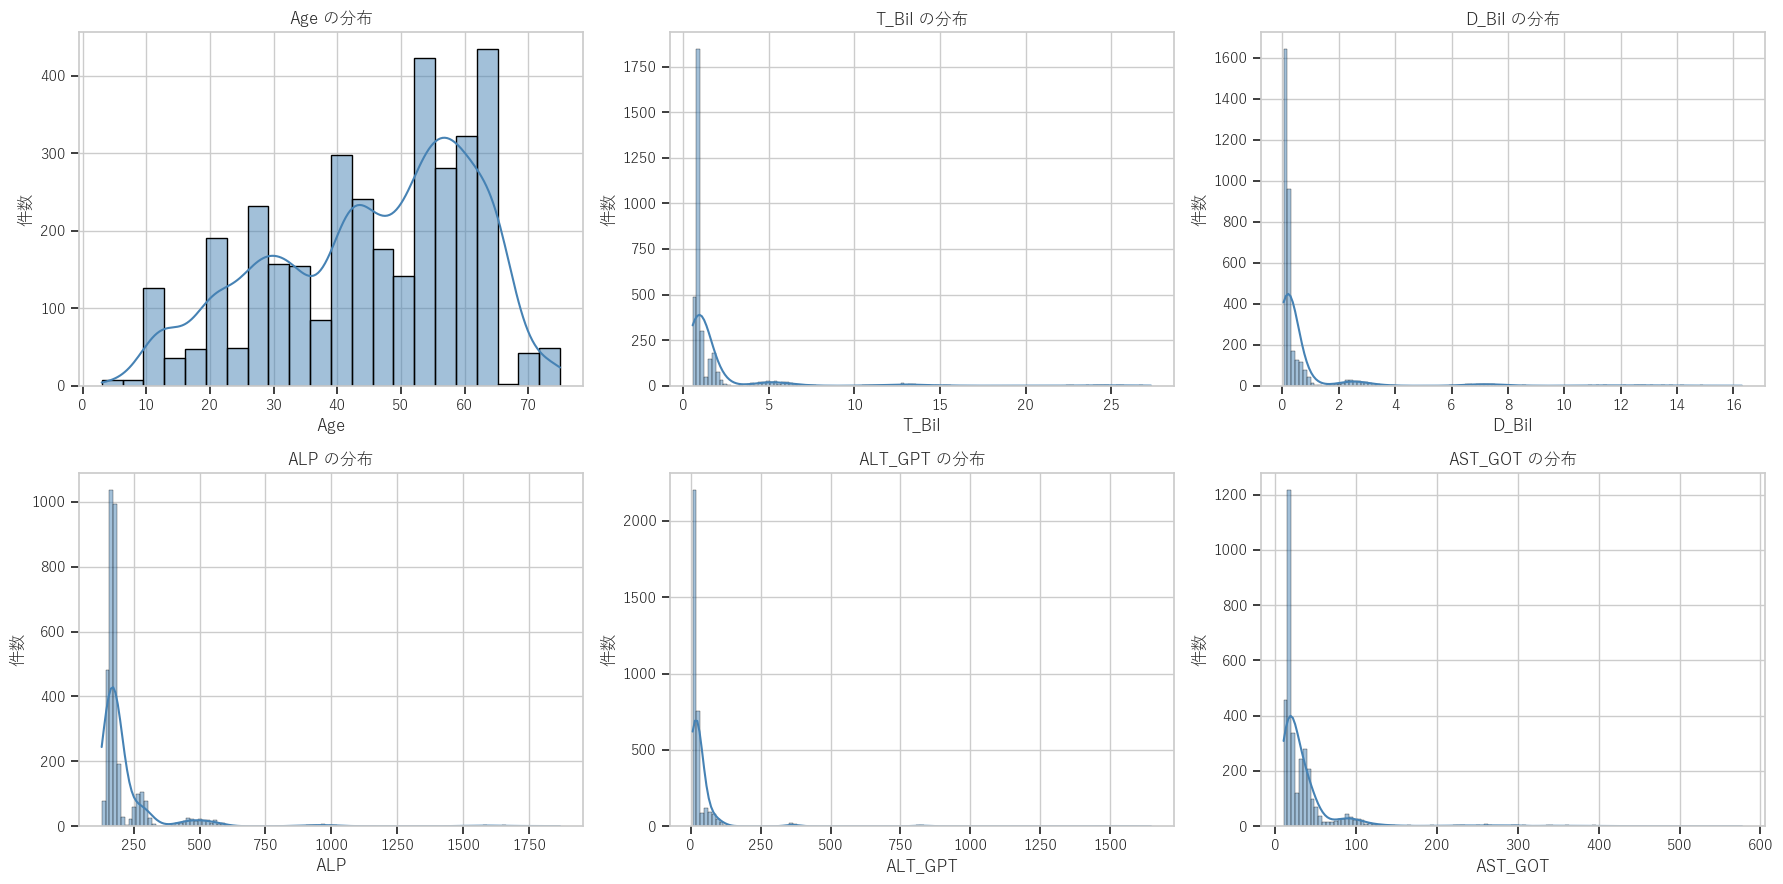

数値列の要約統計量
           count         mean          std         min         25%  \
id        3500.0  1749.500000  1010.507298    0.000000  874.750000   
Age       3500.0    45.325429    15.817554    3.000000   33.000000   
T_Bil     3500.0     1.919269     3.330010    0.553789    0.841287   
D_Bil     3500.0     0.709048     1.783347    0.040161    0.142479   
ALP       3500.0   225.932791   184.208038  129.185799  164.143621   
ALT_GPT   3500.0    39.925959   120.534839    7.150973   15.777688   
AST_GOT   3500.0    39.089220    53.627868   10.565631   16.317539   
TP        3500.0     6.485785     0.871500    3.288138    6.019990   
Alb       3500.0     3.612211     0.713799    1.884264    3.036498   
AG_ratio  3500.0     0.878517     0.230845    0.366190    0.730434   
disease   3500.0     0.413143     0.492468    0.000000    0.000000   

                  50%          75%          max  
id        1749.500000  2624.250000  3499.000000  
Age         48.000000    58.000000    75.000000  

In [5]:
try:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col in numeric_cols:
        numeric_feature_cols = [c for c in numeric_cols if c != target_col]
    else:
        numeric_feature_cols = numeric_cols.copy()
    if 'id' in numeric_feature_cols:
        numeric_feature_cols.remove('id')
    selected_cols = numeric_feature_cols[:6]
    if len(selected_cols) == 0:
        selected_cols = numeric_cols[:6]
    print('数値列一覧')
    print(numeric_cols)
    if len(selected_cols) > 0:
        n = len(selected_cols)
        ncols = 3
        nrows = int(np.ceil(n / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.5 * nrows))
        axes = np.array(axes).reshape(-1)
        for ax, col in zip(axes, selected_cols):
            sns.histplot(df[col].dropna(), kde=True, ax=ax, color='steelblue')
            ax.set_title(f'{col} の分布')
            ax.set_xlabel(col)
            ax.set_ylabel('件数')
        for ax in axes[len(selected_cols):]:
            ax.axis('off')
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'numeric_distribution_top6.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
    print('数値列の要約統計量')
    if len(numeric_cols) > 0:
        print(df[numeric_cols].describe().T)
        q1 = df[numeric_cols].quantile(0.25)
        q3 = df[numeric_cols].quantile(0.75)
        iqr = q3 - q1
        outlier_count = ((df[numeric_cols] < (q1 - 1.5 * iqr)) | (df[numeric_cols] > (q3 + 1.5 * iqr))).sum().sort_values(ascending=False)
        print('外れ値件数(IQR基準)')
        print(outlier_count)
    else:
        print('数値列はありません')
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: numeric_code: {_eda_exc}")
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    if numeric_cols:
        display(df[numeric_cols].describe().T.head(20))
    target_col_local = "disease"
    if target_col_local not in df.columns:
        target_col_local = df.columns[-1]
    plot_cols = [c for c in numeric_cols if c != target_col_local][:6]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i < len(plot_cols):
            col = plot_cols[i]
            sns.histplot(df[col], bins=30, ax=ax, color="#1f77b4")
            ax.set_title(f"{col} の分布")
        else:
            ax.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "numeric_distribution_top6.png", dpi=160, bbox_inches="tight")
    plt.show()


## 4. カテゴリ特徴量の分布


カテゴリ列一覧
['Gender']
Gender の度数分布
Gender
Male      2930
Female     570
Name: count, dtype: int64


C:\Users\hikeshita\AppData\Local\Temp\ipykernel_26524\2964952144.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
C:\Users\hikeshita\AppData\Local\Temp\ipykernel_26524\2964952144.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, palette='viridis')


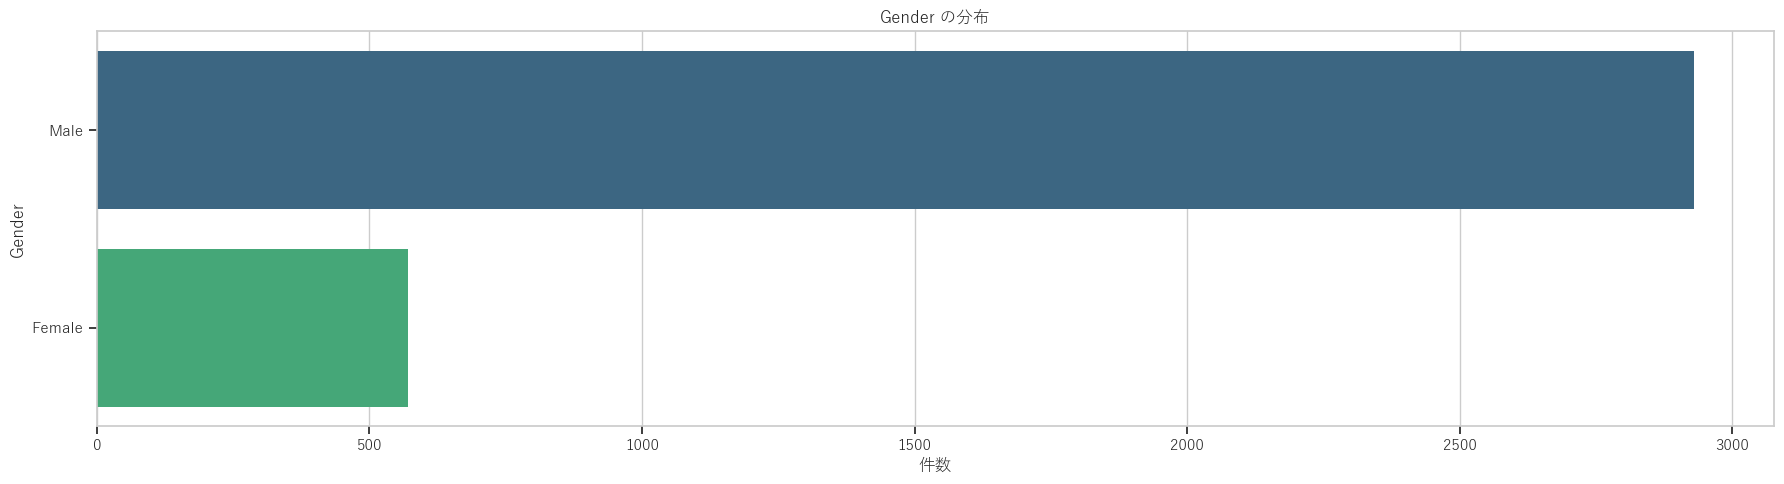

In [6]:
try:
    cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    selected_cat_cols = cat_cols[:3]
    print('カテゴリ列一覧')
    print(cat_cols)
    for col in selected_cat_cols:
        print(f'{col} の度数分布')
        print(df[col].value_counts(dropna=False).head(20))
    plt.figure(figsize=(18, 5))
    if len(selected_cat_cols) > 0:
        for i, col in enumerate(selected_cat_cols, 1):
            plt.subplot(1, len(selected_cat_cols), i)
            vc = df[col].astype(str).value_counts(dropna=False).head(10)
            sns.barplot(x=vc.values, y=vc.index, palette='viridis')
            plt.title(f'{col} の分布')
            plt.xlabel('件数')
            plt.ylabel(col)
        plt.tight_layout()
    else:
        plt.text(0.5, 0.5, 'カテゴリ列はありません', ha='center', va='center', fontsize=14)
        plt.title('カテゴリ列の分布')
        plt.axis('off')
        plt.tight_layout()
    plt.savefig(FIG_DIR / 'categorical_distribution_top3.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: categorical_code: {_eda_exc}")
    category_cols = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
    plot_cols = category_cols[:3]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    for i, ax in enumerate(axes):
        if i < len(plot_cols):
            col = plot_cols[i]
            vc = df[col].astype(str).fillna("欠損").value_counts().head(10)
            vc.plot(kind="bar", ax=ax, color="#59a14f")
            ax.set_title(f"{col} 上位カテゴリ")
            ax.tick_params(axis="x", rotation=45)
        else:
            ax.axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "categorical_distribution_top3.png", dpi=160, bbox_inches="tight")
    plt.show()


## 5. 目的変数分析


目的変数の分布
disease
0    2054
1    1446
Name: count, dtype: int64
目的変数の割合
disease
0    58.69
1    41.31
Name: proportion, dtype: float64


C:\Users\hikeshita\AppData\Local\Temp\ipykernel_26524\2580755668.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, order=order, palette='Set2')


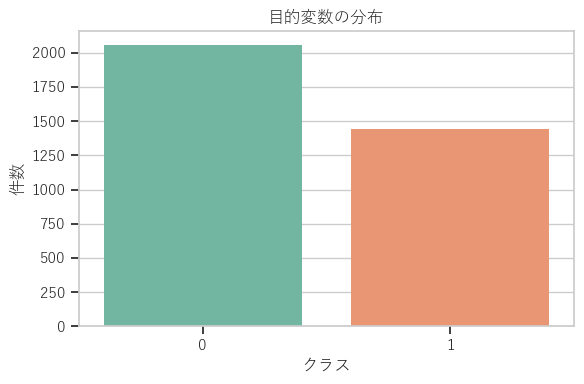

目的変数ごとの数値列平均
               クラス_0       クラス_1
Age        46.494158   43.665284
T_Bil       0.964897    3.274925
D_Bil       0.214108    1.412094
ALP       193.348998  272.217098
ALT_GPT    19.658627   68.715102
AST_GOT    25.257543   58.736706
TP          6.598225    6.326069
Alb         3.774216    3.382087
AG_ratio    0.930002    0.805385


In [7]:
try:
    print('目的変数の分布')
    print(df[target_col].value_counts(dropna=False).sort_index())
    print('目的変数の割合')
    print((df[target_col].value_counts(dropna=False, normalize=True).sort_index() * 100).round(2))
    plt.figure(figsize=(6, 4))
    order = sorted(df[target_col].dropna().unique().tolist())
    sns.countplot(data=df, x=target_col, order=order, palette='Set2')
    plt.title('目的変数の分布')
    plt.xlabel('クラス')
    plt.ylabel('件数')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'target_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != target_col and c != 'id']
    if len(num_cols) > 0:
        diff = df.groupby(target_col)[num_cols].mean().T
        diff.columns = [f'クラス_{c}' for c in diff.columns]
        print('目的変数ごとの数値列平均')
        print(diff)
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: target_code: {_eda_exc}")
    series = df[target_col]
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    if pd.api.types.is_numeric_dtype(series):
        uniq = series.dropna().nunique()
        if uniq > 20:
            sns.histplot(series.dropna(), bins=30, ax=ax[0], color="#f28e2b")
            ax[0].set_title("目的変数ヒストグラム")
            sns.boxplot(x=series.dropna(), ax=ax[1], color="#e15759")
            ax[1].set_title("目的変数ボックスプロット")
        else:
            vc = series.value_counts(dropna=False).sort_index()
            vc.plot(kind="bar", ax=ax[0], color="#f28e2b")
            ax[0].set_title("目的変数カテゴリ分布")
            (vc / vc.sum() * 100).round(2).plot(kind="bar", ax=ax[1], color="#e15759")
            ax[1].set_title("目的変数カテゴリ比率(%)")
    else:
        vc = series.astype(str).fillna("欠損").value_counts().head(20)
        vc.plot(kind="bar", ax=ax[0], color="#f28e2b")
        ax[0].set_title("目的変数カテゴリ分布")
        (vc / vc.sum() * 100).round(2).plot(kind="bar", ax=ax[1], color="#e15759")
        ax[1].set_title("目的変数カテゴリ比率(%)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "target_distribution.png", dpi=160, bbox_inches="tight")
    plt.show()


## 6. 相関分析


相関行列
               Age     T_Bil     D_Bil       ALP   ALT_GPT   AST_GOT  \
Age       1.000000 -0.032856 -0.029669 -0.074980 -0.019116 -0.036955   
T_Bil    -0.032856  1.000000  0.835313  0.064862  0.227029  0.336433   
D_Bil    -0.029669  0.835313  1.000000  0.067416  0.248089  0.335851   
ALP      -0.074980  0.064862  0.067416  1.000000  0.024953  0.066503   
ALT_GPT  -0.019116  0.227029  0.248089  0.024953  1.000000  0.638488   
AST_GOT  -0.036955  0.336433  0.335851  0.066503  0.638488  1.000000   
TP        0.008163 -0.154746 -0.155663 -0.099024 -0.106090 -0.113161   
Alb      -0.002790 -0.209501 -0.197415 -0.176577 -0.051905 -0.110589   
AG_ratio  0.021231 -0.269621 -0.254112 -0.208343 -0.037068 -0.139579   
disease  -0.088075  0.341625  0.330822  0.210849  0.200430  0.307441   

                TP       Alb  AG_ratio   disease  
Age       0.008163 -0.002790  0.021231 -0.088075  
T_Bil    -0.154746 -0.209501 -0.269621  0.341625  
D_Bil    -0.155663 -0.197415 -0.254112  0.330822 

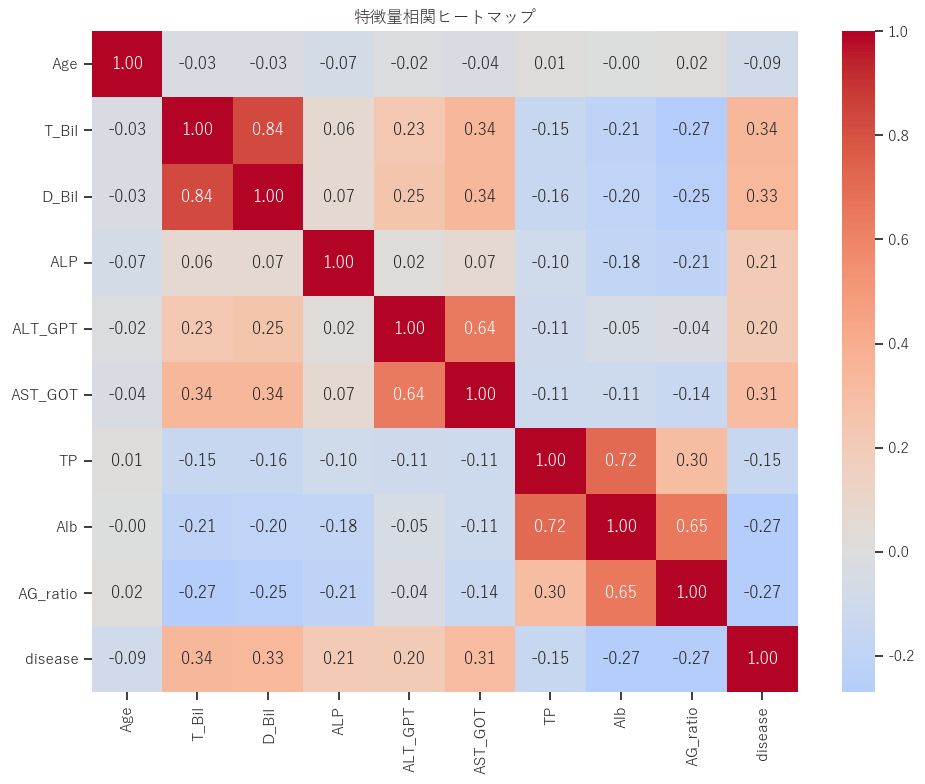

目的変数との相関
T_Bil       0.341625
D_Bil       0.330822
AST_GOT     0.307441
Alb        -0.270540
AG_ratio   -0.265848
ALP         0.210849
ALT_GPT     0.200430
TP         -0.153790
Age        -0.088075
Name: disease, dtype: float64


In [8]:
try:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if 'id' in numeric_cols:
        numeric_cols = [c for c in numeric_cols if c != 'id']
    print('相関行列')
    if len(numeric_cols) >= 2:
        corr = df[numeric_cols].corr(numeric_only=True)
        print(corr)
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=False)
        plt.title('特徴量相関ヒートマップ')
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
        target_corr = corr[target_col].drop(target_col).sort_values(key=lambda s: s.abs(), ascending=False) if target_col in corr.columns else pd.Series(dtype=float)
        print('目的変数との相関')
        print(target_corr)
    else:
        plt.figure(figsize=(8, 4))
        plt.text(0.5, 0.5, '相関を計算できる数値列が不足しています', ha='center', va='center', fontsize=14)
        plt.title('特徴量相関ヒートマップ')
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: corr_code: {_eda_exc}")
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    fig, ax = plt.subplots(figsize=(10, 8))
    if len(numeric_cols) >= 2:
        corr = df[numeric_cols[:20]].corr(numeric_only=True)
        sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)
        ax.set_title("数値特徴量の相関ヒートマップ（先頭20列）")
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, "相関分析に十分な数値列がありません", ha="center", va="center", fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "feature_correlation_heatmap.png", dpi=160, bbox_inches="tight")
    plt.show()


## 7. 日付分析


日付列は検出されませんでした


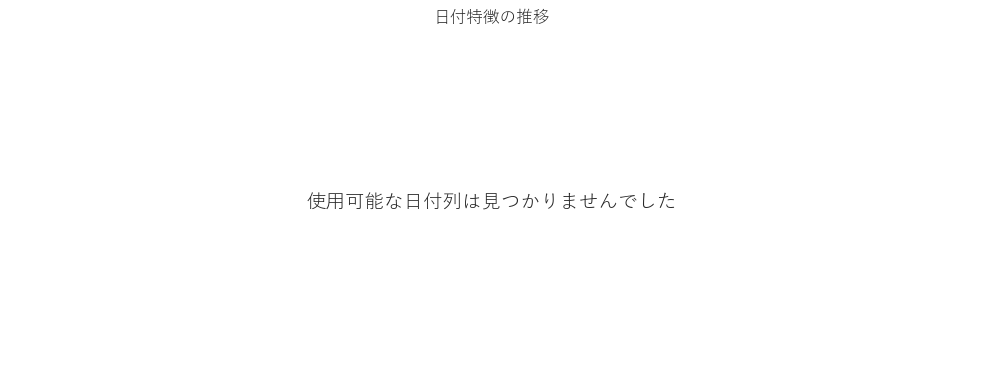

In [9]:
try:
    def is_pure_day_number_column(s):
        x = pd.to_numeric(s, errors='coerce')
        if x.notna().mean() < 0.95:
            return False
        x_non_na = x.dropna()
        if len(x_non_na) == 0:
            return False
        if not np.all(np.isclose(x_non_na % 1, 0)):
            return False
        return x_non_na.between(1, 31).mean() > 0.95

    candidate_col = None
    if date_col_hint not in [None, 'None', '', np.nan] and str(date_col_hint) in df.columns:
        candidate_col = str(date_col_hint)
    else:
        for c in df.columns:
            cl = str(c).lower()
            if any(k in cl for k in ['date', 'day', 'time', 'month', 'year']):
                candidate_col = c
                break

    parsed = None
    used_col = None
    if candidate_col is not None and candidate_col in df.columns and not is_pure_day_number_column(df[candidate_col]):
        temp = pd.to_datetime(df[candidate_col], errors='coerce')
        if temp.notna().sum() > 0:
            parsed = temp
            used_col = candidate_col

    plt.figure(figsize=(10, 4))
    if parsed is not None:
        tmp = pd.DataFrame({'_date': parsed}).dropna().sort_values('_date')
        monthly = tmp.set_index('_date').resample('M').size()
        plt.plot(monthly.index, monthly.values, marker='o')
        plt.title(f'{used_col} の時系列件数推移')
        plt.xlabel('日付')
        plt.ylabel('件数')
        print('日付列として使用:', used_col)
        print('期間:', tmp['_date'].min(), '〜', tmp['_date'].max())
    else:
        plt.text(0.5, 0.5, '使用可能な日付列は見つかりませんでした', ha='center', va='center', fontsize=14)
        plt.title('日付特徴の推移')
        plt.axis('off')
        print('日付列は検出されませんでした')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'date_feature_trend.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: date_code: {_eda_exc}")
    date_col = "None".strip() or date_col_hint
    fig, ax = plt.subplots(figsize=(12, 4))
    if date_col and date_col in df.columns and date_col != target_col:
        pure_day = is_pure_day_number_column(df[date_col])
        if pure_day:
            ax.axis("off")
            ax.text(0.5, 0.5, f"{date_col} は純粋な日番号列のため日付展開を行いません", ha="center", va="center", fontsize=12)
        else:
            parsed = pd.to_datetime(df[date_col], errors="coerce")
            valid = parsed.notna()
            if valid.sum() > 0:
                tmp = df.loc[valid, [target_col]].copy()
                tmp["_date"] = parsed.loc[valid]
                if pd.api.types.is_numeric_dtype(tmp[target_col]):
                    monthly = tmp.set_index("_date")[target_col].resample("M").mean()
                    monthly.plot(ax=ax, color="#4e79a7", marker="o")
                    ax.set_title("月次の目的変数平均")
                    ax.set_ylabel("平均値")
                else:
                    monthly = tmp.assign(_value=1).set_index("_date")["_value"].resample("M").sum()
                    monthly.plot(ax=ax, color="#4e79a7", marker="o")
                    ax.set_title("月次レコード件数")
                    ax.set_ylabel("件数")
                ax.set_xlabel("日付")
            else:
                ax.axis("off")
                ax.text(0.5, 0.5, f"{date_col} を日付として解釈できませんでした", ha="center", va="center", fontsize=12)
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, "日付分析対象列はありません", ha="center", va="center", fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "date_feature_trend.png", dpi=160, bbox_inches="tight")
    plt.show()


## 8. 観察結果サマリ


In [10]:
try:
    print('EDA要約')
    print(f'データ形状: {df.shape[0]}行 × {df.shape[1]}列')
    missing_total = int(df.isna().sum().sum())
    print(f'総欠損数: {missing_total}')
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    print(f'数値列数: {len(num_cols)}')
    print(f'カテゴリ列数: {len(cat_cols)}')
    if target_col in df.columns:
        print('目的変数分布')
        print(df[target_col].value_counts(dropna=False).sort_index())
    if len(num_cols) > 0:
        summary_stats = df[num_cols].describe().T[['mean', 'std', 'min', 'max']]
        print('主要統計量')
        print(summary_stats)
        if target_col in num_cols and len(num_cols) > 1:
            corr_to_target = df[num_cols].corr(numeric_only=True)[target_col].drop(target_col).sort_values(key=lambda s: s.abs(), ascending=False)
            print('目的変数と相関の強い順')
            print(corr_to_target)
    print('分析対象列')
    print(df.columns.tolist())
except Exception as _eda_exc:
    print(f"[warn] EDA section fallback: summary_code: {_eda_exc}")
    summary_rows = []
    summary_rows.append(f"レコード数: {len(df):,}")
    summary_rows.append(f"列数: {df.shape[1]:,}")
    summary_rows.append(f"欠損率上位列: {', '.join((df.isna().mean()*100).sort_values(ascending=False).head(3).index.tolist())}")
    summary_rows.append(f"数値列数: {len(df.select_dtypes(include=['number']).columns)}")
    summary_rows.append(f"カテゴリ列数: {len([c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])])}")
    summary_rows.append(f"目的変数候補: {target_col}")
    print("主要サマリ")
    for row in summary_rows:
        print(f"- {row}")


EDA要約
データ形状: 3500行 × 12列
総欠損数: 0
数値列数: 11
カテゴリ列数: 1
目的変数分布
disease
0    2054
1    1446
Name: count, dtype: int64
主要統計量
                 mean          std         min          max
id        1749.500000  1010.507298    0.000000  3499.000000
Age         45.325429    15.817554    3.000000    75.000000
T_Bil        1.919269     3.330010    0.553789    27.310913
D_Bil        0.709048     1.783347    0.040161    16.300769
ALP        225.932791   184.208038  129.185799  1866.147334
ALT_GPT     39.925959   120.534839    7.150973  1645.254290
AST_GOT     39.089220    53.627868   10.565631   577.200793
TP           6.485785     0.871500    3.288138     8.046774
Alb          3.612211     0.713799    1.884264     4.701661
AG_ratio     0.878517     0.230845    0.366190     2.651567
disease      0.413143     0.492468    0.000000     1.000000
目的変数と相関の強い順
T_Bil       0.341625
D_Bil       0.330822
AST_GOT     0.307441
Alb        -0.270540
AG_ratio   -0.265848
ALP         0.210849
ALT_GPT     0.200430
TP

C:\Users\hikeshita\AppData\Local\Temp\ipykernel_26524\197379655.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
